In [ ]:
# import sys
# !{sys.executable} -m pip install xgboost

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import glob

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [4]:
print(os.getcwd())
print(os.listdir('D:/AI_Study/GitHub/Battery/Data/'))

d:\AI_Study\GitHub\Battery
['ML_DATA_Extract_Row_0(비교용).csv', 'ML_DATA_Extract_Row_1.csv', 'ML_DATA_Extract_Row_10.csv', 'ML_DATA_Extract_Row_102.csv', 'ML_DATA_Extract_Row_103.csv', 'ML_DATA_Extract_Row_104.csv', 'ML_DATA_Extract_Row_105.csv', 'ML_DATA_Extract_Row_106.csv', 'ML_DATA_Extract_Row_109.csv', 'ML_DATA_Extract_Row_11.csv', 'ML_DATA_Extract_Row_110.csv', 'ML_DATA_Extract_Row_111.csv', 'ML_DATA_Extract_Row_112.csv', 'ML_DATA_Extract_Row_113.csv', 'ML_DATA_Extract_Row_115.csv', 'ML_DATA_Extract_Row_116.csv', 'ML_DATA_Extract_Row_117.csv', 'ML_DATA_Extract_Row_118.csv', 'ML_DATA_Extract_Row_119.csv', 'ML_DATA_Extract_Row_121.csv', 'ML_DATA_Extract_Row_122.csv', 'ML_DATA_Extract_Row_123.csv', 'ML_DATA_Extract_Row_124.csv', 'ML_DATA_Extract_Row_127.csv', 'ML_DATA_Extract_Row_128.csv', 'ML_DATA_Extract_Row_13.csv', 'ML_DATA_Extract_Row_131.csv', 'ML_DATA_Extract_Row_132.csv', 'ML_DATA_Extract_Row_134.csv', 'ML_DATA_Extract_Row_135.csv', 'ML_DATA_Extract_Row_136.csv', 'ML_DATA_Extr

In [5]:
# # 1. 파일들이 있는 정확한 폴더 경로
# path = 'D:\AI_Study\GitHub\Battery\Data'

# # 2. 해당 폴더에서 .csv로 끝나는 모든 파일 목록 가져오기
# # (파일명을 직접 입력하는 것보다 훨씬 안전합니다)
# file_list = glob.glob(os.path.join(path, "*.csv"))

# print(f"찾은 파일 개수: {len(file_list)}개") # 여기서 0이 나오면 경로가 틀린 것입니다.

# if len(file_list) > 0:
#     datas = []
#     for file in file_list:
#         data = pd.read_csv(file)
#         datas.append(data)
    
#     df_combined = pd.concat(datas, ignore_index=True)
#     print("병합 성공!")
# else:
#     print("파일을 찾을 수 없습니다. 경로를 다시 확인해주세요.")
#     # 현재 위치의 폴더 구조를 출력해보기
#     print("현재 작업 디렉토리:", os.getcwd())

In [6]:
datas = []

for a in range(0,487):
    file_path = f'D:\AI_Study\GitHub\Battery\Data\ML_DATA_Extract_Row_{a}.csv'
    
    # 파일이 존재하는지 확인하는 예외 처리를 추가하면 안전합니다
    if os.path.exists(file_path):
        data = pd.read_csv(file_path)
        datas.append(data)

# 데이터프레임들을 하나로 합치기
df_combined = pd.concat(datas, ignore_index=True)
df_combined

,Time,TempBase,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,0.10000,119.772491,-0.093900,-34.039048,-4.611648,35.953964,0.001978,0.018626,-2.479831,-5.445917,-2.658814,27.851064,0.001952,0.026744,-2.414072,58.597932,-85.012494
1,0.20000,119.342079,-0.091918,-33.117296,-4.321274,34.870854,0.001930,0.018245,-2.405363,-5.392631,-2.594982,27.350767,0.001923,0.026047,-2.349079,57.581262,-82.475316
2,0.35000,116.146805,-0.087046,-30.063202,-3.425492,31.347935,0.001758,0.016425,-2.151174,-5.191143,-2.391990,25.760874,0.001823,0.023751,-2.123403,54.532040,-75.202100
3,0.57500,102.367302,-0.077408,-21.335327,-1.069542,21.684202,0.001290,0.011473,-1.439919,-4.453914,-1.874074,21.437436,0.001539,0.016897,-1.481788,46.687801,-56.980162
4,0.91250,102.367302,-0.077405,-21.258666,-1.108848,21.618139,0.001305,0.011256,-1.440604,-4.407878,-1.863347,21.377225,0.001540,0.017055,-1.481196,46.690991,-56.968759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221621,298.41250,22.001497,-0.060728,19.993435,6.595332,26.180698,0.003246,-0.028462,1.161866,0.880817,-0.055972,6.080573,0.000690,-0.005688,1.136165,6.934369,37.434713
221622,298.91250,22.001497,-0.060729,19.991191,6.594960,26.178368,0.003247,-0.028461,1.161874,0.880439,-0.055893,6.080661,0.000690,-0.005687,1.136169,6.929718,37.415032
221623,299.41250,22.001497,-0.060730,19.988981,6.594595,26.176077,0.003247,-0.028461,1.161881,0.880066,-0.055813,6.080746,0.000690,-0.005686,1.136173,6.925078,37.395483
221624,299.70625,22.001497,-0.060731,19.987697,6.594384,26.174747,0.003247,-0.028460,1.161886,0.879849,-0.055767,6.080794,0.000690,-0.005685,1.136176,6.922356,37.384046


In [7]:
df_combined.head()

,Time,TempBase,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,0.1000,119.772491,-0.093900,-34.039048,-4.611648,35.953964,0.001978,0.018626,-2.479831,-5.445917,-2.658814,27.851064,0.001952,0.026744,-2.414072,58.597932,-85.012494
1,0.2000,119.342079,-0.091918,-33.117296,-4.321274,34.870854,0.001930,0.018245,-2.405363,-5.392631,-2.594982,27.350767,0.001923,0.026047,-2.349079,57.581262,-82.475316
2,0.3500,116.146805,-0.087046,-30.063202,-3.425492,31.347935,0.001758,0.016425,-2.151174,-5.191143,-2.391990,25.760874,0.001823,0.023751,-2.123403,54.532040,-75.202100
3,0.5750,102.367302,-0.077408,-21.335327,-1.069542,21.684202,0.001290,0.011473,-1.439919,-4.453914,-1.874074,21.437436,0.001539,0.016897,-1.481788,46.687801,-56.980162
4,0.9125,102.367302,-0.077405,-21.258666,-1.108848,21.618139,0.001305,0.011256,-1.440604,-4.407878,-1.863347,21.377225,0.001540,0.017055,-1.481196,46.690991,-56.968759


In [8]:
df_combined.tail()

,Time,TempBase,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
221621,298.41250,22.001497,-0.060728,19.993435,6.595332,26.180698,0.003246,-0.028462,1.161866,0.880817,-0.055972,6.080573,0.00069,-0.005688,1.136165,6.934369,37.434713
221622,298.91250,22.001497,-0.060729,19.991191,6.594960,26.178368,0.003247,-0.028461,1.161874,0.880439,-0.055893,6.080661,0.00069,-0.005687,1.136169,6.929718,37.415032
221623,299.41250,22.001497,-0.060730,19.988981,6.594595,26.176077,0.003247,-0.028461,1.161881,0.880066,-0.055813,6.080746,0.00069,-0.005686,1.136173,6.925078,37.395483
221624,299.70625,22.001497,-0.060731,19.987697,6.594384,26.174747,0.003247,-0.028460,1.161886,0.879849,-0.055767,6.080794,0.00069,-0.005685,1.136176,6.922356,37.384046
221625,300.00000,22.001497,-0.060731,19.986425,6.594175,26.173430,0.003247,-0.028460,1.161890,0.879633,-0.055721,6.080841,0.00069,-0.005685,1.136179,6.919636,37.372651


In [9]:
datas = []

df = pd.read_csv('D:\AI_Study\GitHub\Battery\Master_DOE_1200.csv')
df.head()

,P1,P2,P3,P4,P5,P6
0,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585
1,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696
2,0.8013,0.0512,0.6363,0.2312,1.3751,0.0560
3,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777
4,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779


In [10]:
df.tail()

,P1,P2,P3,P4,P5,P6
1195,0.9105,0.0724,0.6618,0.1579,1.5180,0.0507
1196,0.8535,0.0812,0.6761,0.1703,1.7806,0.0537
1197,0.8733,0.0796,0.6174,0.2134,1.6338,0.0657
1198,1.0840,0.0760,0.7187,0.1488,1.6888,0.0733
1199,0.9104,0.0503,0.7195,0.1772,1.6129,0.0649


In [11]:
data = pd.read_csv('D:\AI_Study\GitHub\Battery\Data\ML_DATA_Extract_Row_0(비교용).csv')
data.head()

,Time,TempBase,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,0.1000,119.783188,-0.117491,-33.906822,-4.554427,35.676788,0.002045,0.006655,-2.664144,-4.176999,-2.040079,24.093281,0.001651,-0.013850,-2.666389,60.788027,-90.517540
1,0.2000,119.365982,-0.114489,-32.821039,-4.190090,34.399391,0.001985,0.006968,-2.571259,-4.121848,-1.983519,23.631296,0.001624,-0.013271,-2.582500,59.493175,-87.189336
2,0.3500,116.013115,-0.107182,-29.215017,-3.082544,30.259626,0.001774,0.006249,-2.259908,-3.933210,-1.775690,22.038879,0.001525,-0.011675,-2.296628,55.720295,-77.932456
3,0.5750,100.949310,-0.093217,-18.910070,-0.244393,19.104284,0.001226,0.003298,-1.398259,-3.295966,-1.172539,17.294662,0.001220,-0.008947,-1.491133,46.510018,-55.918074
4,0.9125,100.949310,-0.093213,-18.852267,-0.290878,19.049131,0.001240,0.003495,-1.398741,-3.267223,-1.165693,17.252942,0.001220,-0.008968,-1.490320,46.512853,-55.899300


In [12]:
np.random.seed(42)
n_samples = 800
data = pd.DataFrame({
    'P1': np.random.uniform(10, 50, n_samples),
    'P2': np.random.uniform(100, 200, n_samples),
    'P3': np.random.uniform(0.1, 0.5, n_samples),
    'P4': np.random.uniform(5, 15, n_samples),
    'P5': np.random.uniform(1, 5, n_samples),
    'P6': np.random.uniform(20, 80, n_samples),
    'Max_Peak': np.random.normal(500, 50, n_samples) # 예측 대상(Y)
})

### 탐색적 데이터 분석(EDA)

In [13]:
# 기본 정보
print('='*60)
print('데이터 정보')
print('='*60)
data.info()

데이터 정보
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   P1        800 non-null    float64
 1   P2        800 non-null    float64
 2   P3        800 non-null    float64
 3   P4        800 non-null    float64
 4   P5        800 non-null    float64
 5   P6        800 non-null    float64
 6   Max_Peak  800 non-null    float64
dtypes: float64(7)
memory usage: 43.9 KB


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   P1      1200 non-null   float64
 1   P2      1200 non-null   float64
 2   P3      1200 non-null   float64
 3   P4      1200 non-null   float64
 4   P5      1200 non-null   float64
 5   P6      1200 non-null   float64
dtypes: float64(6)
memory usage: 56.4 KB


In [15]:
df_combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 221626 entries, 0 to 221625
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Time           221626 non-null  float64
 1    TempBase      221626 non-null  float64
 2    WarpMax       221626 non-null  float64
 3    T_Tip_Peel    221626 non-null  float64
 4    T_Tip_Shear   221626 non-null  float64
 5    T_Tip_SEQV    221626 non-null  float64
 6    T_Tip_Strain  221626 non-null  float64
 7    T_Avg_Peel    221626 non-null  float64
 8    T_Avg_Shear   221626 non-null  float64
 9    B_Tip_Peel    221626 non-null  float64
 10   B_Tip_Shear   221626 non-null  float64
 11   B_Tip_SEQV    221626 non-null  float64
 12   B_Tip_Strain  221626 non-null  float64
 13   B_Avg_Peel    221626 non-null  float64
 14   B_Avg_Shear   221626 non-null  float64
 15   Die_SX        221626 non-null  float64
 16   Die_SY_Max    221626 non-null  float64
dtypes: float64(17)
memory usage: 28.7 MB


In [18]:
# ---------------------------------------------------------
# [Step 0] 데이터 로드 (가상의 800개 생존 데이터 예시)
# ---------------------------------------------------------
# 실제 데이터가 있다면 pd.read_csv()를 사용하세요.
# 여기서는 P1~P6 입력과 Y(Max Peak) 출력 구조를 가정합니다.
np.random.seed(42)
n_samples = 800
data = pd.DataFrame({
    'P1': np.random.uniform(10, 50, n_samples),
    'P2': np.random.uniform(100, 200, n_samples),
    'P3': np.random.uniform(0.1, 0.5, n_samples),
    'P4': np.random.uniform(5, 15, n_samples),
    'P5': np.random.uniform(1, 5, n_samples),
    'P6': np.random.uniform(20, 80, n_samples),
    'Max_Peak': np.random.normal(500, 50, n_samples) # 예측 대상(Y)
})

### Data Summary ###
               P1          P2          P3          P4          P5          P6  \
count  800.000000  800.000000  800.000000  800.000000  800.000000  800.000000   
mean    29.878253  150.011905    0.299557   10.004099    2.964764   49.562117   
std     11.744276   29.291512    0.114958    2.911849    1.149190   17.118876   
min     10.202463  100.463202    0.100626    5.000116    1.002614   20.001843   
25%     19.657025  123.543979    0.201542    7.655187    1.933944   34.887147   
50%     30.269981  150.471491    0.303557    9.950364    2.942450   50.000518   
75%     40.146774  173.951354    0.398527   12.542524    3.992908   63.772267   
max     49.988707  199.941373    0.499339   14.978209    4.998231   79.864963   

         Max_Peak  
count  800.000000  
mean   496.548299  
std     48.964598  
min    349.618383  
25%    463.744592  
50%    497.274319  
75%    529.298480  
max    657.602837  


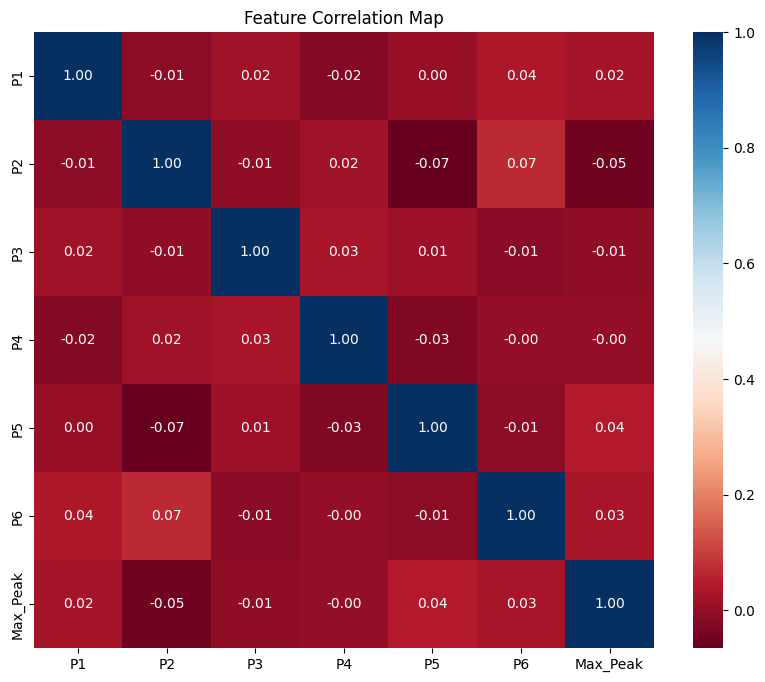

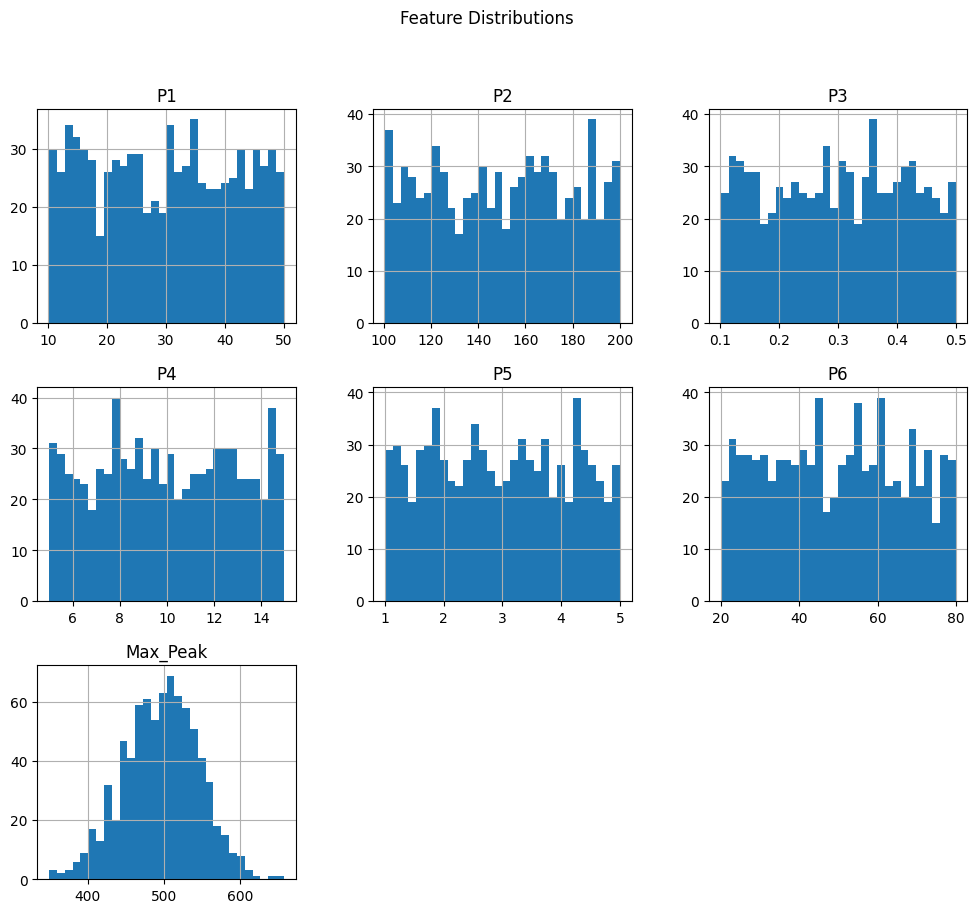

R2 Score: -0.2191
MAE: 41.0242

### 가상 데이터 생성 완료: (100000, 7) ###
          P1          P2        P3         P4        P5         P6  \
0  17.123826  173.573975  0.104209  13.591606  4.437825  24.153524   
1  24.573893  166.971139  0.347558   6.420239  3.214266  58.124071   
2  35.558322  137.816308  0.366200   6.771710  2.244613  44.552634   
3  13.015216  163.072725  0.280275   9.620066  4.234545  78.192963   
4  24.586789  115.540011  0.127836   5.947291  2.583947  68.935179   

   Max_Peak_Predicted  
0          474.380035  
1          490.442352  
2          477.229279  
3          473.599609  
4          501.057404  


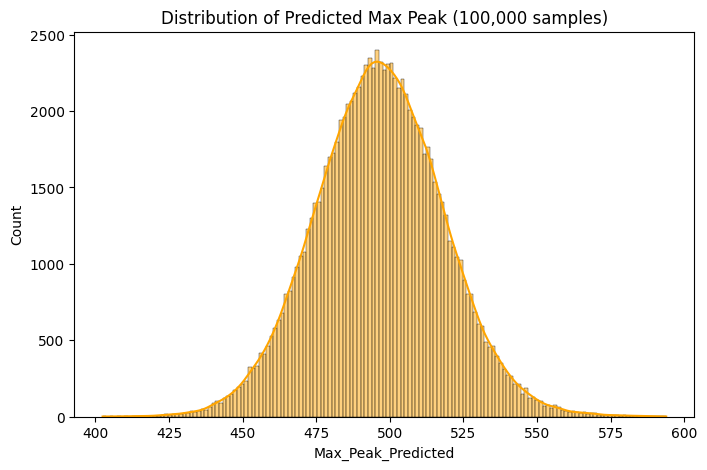

In [ ]:

# ---------------------------------------------------------
# [Step 1] EDA (탐색적 데이터 분석)
# ---------------------------------------------------------
print("### Data Summary ###")
print(data.describe())

# 상관관계 히트맵: 어떤 변수가 Max Peak에 큰 영향을 주는지 확인
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, cmap='RdBu', fmt='.2f')
plt.title("Feature Correlation Map")
plt.show()

# 변수별 분포 확인 (Histogram)
data.hist(bins=30, figsize=(12, 10))
plt.suptitle("Feature Distributions")
plt.show()

# ---------------------------------------------------------
# [Step 2] 대리 모델(Surrogate Model) 학습 - XGBoost
# ---------------------------------------------------------
X = data[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']]
y = data['Max_Peak']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# XGBoost 회귀 모델 생성 및 학습
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# 모델 성능 검증
y_pred = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

# ---------------------------------------------------------
# [Step 3] Monte Carlo 기반 가상 데이터 생성 (Data Augmentation)
# ---------------------------------------------------------
# 목표: 10만 개의 가상 조합 생성
n_virtual = 100000

# 기존 데이터의 범위를 참고하여 난수 생성 (Uniform 또는 Normal 분포 선택 가능)
virtual_X = pd.DataFrame({
    'P1': np.random.uniform(data['P1'].min(), data['P1'].max(), n_virtual),
    'P2': np.random.uniform(data['P2'].min(), data['P2'].max(), n_virtual),
    'P3': np.random.uniform(data['P3'].min(), data['P3'].max(), n_virtual),
    'P4': np.random.uniform(data['P4'].min(), data['P4'].max(), n_virtual),
    'P5': np.random.uniform(data['P5'].min(), data['P5'].max(), n_virtual),
    'P6': np.random.uniform(data['P6'].min(), data['P6'].max(), n_virtual)
})

# 학습된 대리 모델을 이용해 10만 개의 Y값 예측
virtual_Y = model.predict(virtual_X)

# 입력값과 예측값을 합쳐서 가상 데이터셋 완성
augmented_data = virtual_X.copy()
augmented_data['Max_Peak_Predicted'] = virtual_Y

print(f"\n### 가상 데이터 생성 완료: {augmented_data.shape} ###")
print(augmented_data.head())

# 가상 데이터 분포 확인
plt.figure(figsize=(8, 5))
sns.histplot(augmented_data['Max_Peak_Predicted'], color='orange', kde=True)
plt.title("Distribution of Predicted Max Peak (100,000 samples)")
plt.show()

# ---------------------------------------------------------
# [Step 4] 결과 저장
# ---------------------------------------------------------
# augmented_data.to_csv('augmented_battery_data.csv', index=False)